# 01 Mean Reversion

**Book:** *Fixed Income Relative Value Analysis (2nd ed.)*  
**Focus:** Chapter 2 mean reversion scaffold with a practical local proxy for the book's USD swap butterfly examples.

This notebook uses the locally available Treasury `2s5s10s` butterfly (`2 * DGS5 - DGS2 - DGS10`) as a stand-in for a USD swaps butterfly until direct swap-curve data is added to the lake.


## Goals

1. Load a real fixed-income spread proxy from local data.
2. Build a reusable Ornstein-Uhlenbeck fitting workflow.
3. Scaffold diagnostics, conditional expectation, and simple trade-rule placeholders.
4. Record what should be swapped out once USD swap data becomes available.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from alpha_research.quant_data.api import get_data

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

START = "2024-02-26"
END = "2026-02-27"
BOOK_PDF = Path(r"""/Users/zelin/Desktop/阅读学习/Fixed Income Relative Value Analysis + Website A Practitioner’s Guide to the Theory, Tools, and Trades 2nd.pdf""")

print("Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.")
print("Book PDF exists:", BOOK_PDF.exists())
print("Repo root:", REPO_ROOT)


Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.
Book PDF exists: True
Repo root: /Users/zelin/Desktop/PA Investment/Invest_strategy


In [2]:
FRED_DIR = REPO_ROOT / "data" / "market_data" / "fred"
PRICES_DIR = REPO_ROOT / "data" / "market_data" / "prices"

def _filter_date(frame: pd.DataFrame, start=START, end=END, date_col="date"):
    out = frame.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    return out[(out[date_col] >= start) & (out[date_col] <= end)]

def load_fred_series(series_ids, start=START, end=END):
    frames = []
    for parquet_file in sorted(FRED_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "series_id" not in df.columns:
            continue
        sub = df[df["series_id"].isin(series_ids)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "series_id"])
    wide = (
        joined.pivot(index="date", columns="series_id", values="value")
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide

def load_local_price_series(tickers, start=START, end=END, value_col="close"):
    frames = []
    for parquet_file in sorted(PRICES_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "ticker" not in df.columns or value_col not in df.columns:
            continue
        sub = df[df["ticker"].isin(tickers)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "ticker"])
    wide = (
        joined.pivot(index="date", columns="ticker", values=value_col)
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


In [3]:
curve = load_fred_series(["DGS2", "DGS5", "DGS10", "SOFR"])
curve["UST_2s5s10s_bfly"] = 2 * curve["DGS5"] - curve["DGS2"] - curve["DGS10"]

spread = curve[["DGS2", "DGS5", "DGS10", "SOFR", "UST_2s5s10s_bfly"]].dropna().copy()
spread.tail()


series_id   DGS2  DGS5  DGS10  SOFR  UST_2s5s10s_bfly
date                                                 
2026-02-18  3.47  3.66   4.09  3.73             -0.24
2026-02-19  3.47  3.65   4.08  3.67             -0.25
2026-02-20  3.48  3.65   4.08  3.66             -0.26
2026-02-23  3.43  3.59   4.03  3.66             -0.28
2026-02-25  3.45  3.61   4.05  3.67             -0.28

## Plot the proxy spread

The book's examples often use swap-curve structures. Here we start with the Treasury proxy to validate the notebook plumbing and OU workflow.


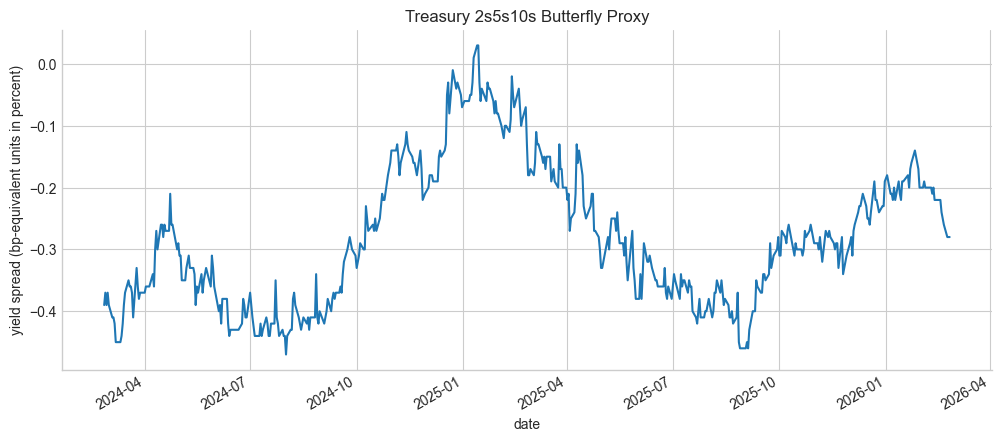

In [4]:
ax = spread["UST_2s5s10s_bfly"].plot(title="Treasury 2s5s10s Butterfly Proxy")
ax.set_ylabel("yield spread (bp-equivalent units in percent)")
plt.show()


## Simple OU fit scaffold

We fit the discrete-time approximation:

\[
X_{t+1} = a + b X_t + \varepsilon_t
\]

and recover continuous-time OU parameters:

- mean-reversion speed `theta`
- long-run mean `mu`
- innovation volatility proxy `sigma`


In [5]:
def fit_ou(series: pd.Series, dt: float = 1.0):
    x = series.dropna().astype(float)
    x_t = x.iloc[:-1].to_numpy()
    x_tp1 = x.iloc[1:].to_numpy()
    X = np.column_stack([np.ones_like(x_t), x_t])
    beta, *_ = np.linalg.lstsq(X, x_tp1, rcond=None)
    a, b = beta

    b_clipped = np.clip(b, 1e-6, 0.999999)
    theta = -np.log(b_clipped) / dt
    mu = a / max(1 - b, 1e-8)

    fitted = a + b * x_t
    resid = x_tp1 - fitted
    sigma_e = resid.std(ddof=1)
    sigma = sigma_e * np.sqrt(2 * theta / max(1 - b**2, 1e-8))

    half_life = np.log(2) / max(theta, 1e-8)
    zscore = (x - x.mean()) / x.std(ddof=1)

    return {
        "a": a,
        "b": b,
        "theta": theta,
        "mu": mu,
        "sigma_e": sigma_e,
        "sigma": sigma,
        "half_life": half_life,
        "residuals": pd.Series(resid, index=x.index[1:]),
        "zscore": zscore,
    }


ou = fit_ou(spread["UST_2s5s10s_bfly"])
pd.Series({k: v for k, v in ou.items() if not isinstance(v, pd.Series)})


a            -0.006717
b             0.975349
theta         0.024960
mu           -0.272470
sigma_e       0.024324
sigma         0.024628
half_life    27.770468

## Diagnostics placeholders

Use this section to add:

- drift diagnostics from the book
- diffusion diagnostics
- conditional density approximations
- first-passage-time approximations
- execution threshold optimization


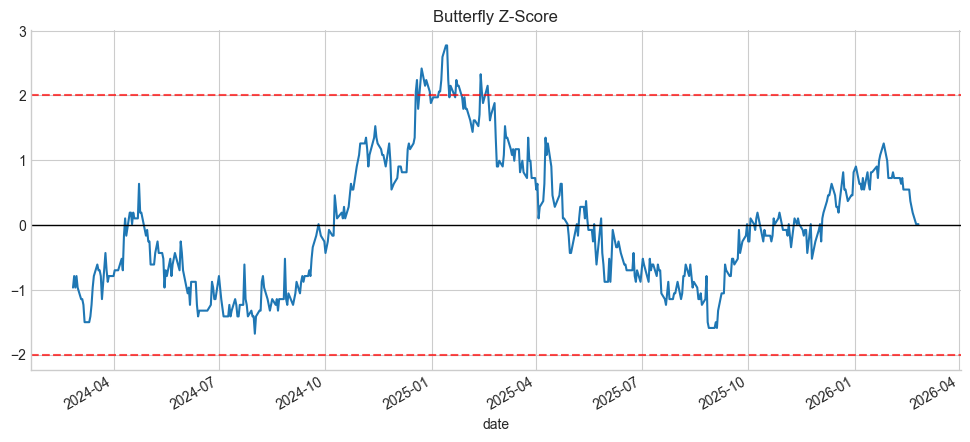

In [6]:
spread["zscore"] = ou["zscore"]
spread[["UST_2s5s10s_bfly", "zscore"]].tail()

ax = spread["zscore"].plot(title="Butterfly Z-Score")
ax.axhline(2.0, color="red", linestyle="--", alpha=0.7)
ax.axhline(-2.0, color="red", linestyle="--", alpha=0.7)
ax.axhline(0.0, color="black", linewidth=1.0)
plt.show()


In [7]:
# TODO: add a richer drift/diffusion diagnostic panel analogous to the book's Chapter 2 figures.
# Example ideas:
# 1. local linear or kernel estimate of drift(x)
# 2. diffusion estimate by state bucket
# 3. conditional expected return over holding horizons
# 4. first-passage-time Monte Carlo or approximation


## Data gap note

Replace the Treasury proxy with real USD swap tenors once swap-curve data is ingested.
Suggested future inputs:

- USD swap 2Y / 5Y / 10Y par rates
- daily carry and roll-down estimates
- transaction-cost assumptions for swap structures


## Regime-conditioned MR-1 signal analysis

The **MR-1** signal is the Chapter 2 mean-reversion signal built from the Treasury `2s5s10s` butterfly proxy.

We classify a signal as:

- `+1` when the butterfly is sufficiently cheap relative to history
- `-1` when it is sufficiently rich
- `0` otherwise

Then we evaluate hit rate and regime-specific half-life using the daily macro regime panel from `08_macro_regime_panel.ipynb`.


In [8]:
STUDY_DIR = REPO_ROOT / 'workstation' / 'playground' / 'studies' / '2026-03-26_fixed_income_relative_value_analysis_2e'
REGIME_PARQUET = STUDY_DIR / 'macro_regime_daily.parquet'

spread["signal"] = np.where(spread["zscore"] < -1.5, 1, np.where(spread["zscore"] > 1.5, -1, 0))
eval_horizon = int(max(5, min(60, round(float(ou["half_life"])))) )
spread["forward_change"] = spread["UST_2s5s10s_bfly"].shift(-eval_horizon) - spread["UST_2s5s10s_bfly"]
spread["hit"] = np.where(spread["signal"] == 0, np.nan, (spread["signal"] * spread["forward_change"] > 0).astype(float))

regime_daily = pd.read_parquet(REGIME_PARQUET)
regime_daily.index = pd.to_datetime(regime_daily.index)

mr_regime = spread.join(regime_daily[["regime"]], how='left')
mr_regime[["UST_2s5s10s_bfly", "zscore", "signal", "regime"]].tail(10)


series_id   UST_2s5s10s_bfly    zscore  signal          regime
date                                                          
2026-02-10             -0.21  0.636136       0    stable carry
2026-02-11             -0.20  0.725174       0    stable carry
2026-02-12             -0.22  0.547099       0    stable carry
2026-02-13             -0.22  0.547099       0  funding stress
2026-02-17             -0.22  0.547099       0  funding stress
2026-02-18             -0.24  0.369023       0  funding stress
2026-02-19             -0.25  0.279986       0  funding stress
2026-02-20             -0.26  0.190948       0  funding stress
2026-02-23             -0.28  0.012873       0  funding stress
2026-02-25             -0.28  0.012873       0  funding stress

In [9]:
mr_hit_rate = (
    mr_regime[mr_regime["signal"] != 0]
    .groupby("regime")
    .agg(signal_count=("signal", "size"), hit_rate=("hit", "mean"), avg_forward_change=("forward_change", "mean"))
    .sort_values("hit_rate", ascending=False)
)

def regime_half_life(series: pd.Series):
    x = series.dropna().astype(float)
    if len(x) < 30:
        return np.nan
    x_t = x.iloc[:-1].to_numpy()
    x_tp1 = x.iloc[1:].to_numpy()
    X = np.column_stack([np.ones_like(x_t), x_t])
    beta, *_ = np.linalg.lstsq(X, x_tp1, rcond=None)
    _, b = beta
    b = np.clip(b, 1e-6, 0.999999)
    theta = -np.log(b)
    return float(np.log(2) / max(theta, 1e-8))

mr_half_life = mr_regime.groupby("regime")["UST_2s5s10s_bfly"].apply(regime_half_life).rename("half_life")
mr_regime_summary = mr_hit_rate.join(mr_half_life)
mr_regime_summary


                 signal_count  hit_rate  avg_forward_change  half_life
regime                                                                
growth scare                4  1.000000            0.160000   2.171263
inflation shock            37  1.000000           -0.063243  11.151239
funding stress              6  0.833333           -0.006667   4.220190
stable carry                9  0.666667           -0.017778  14.805112

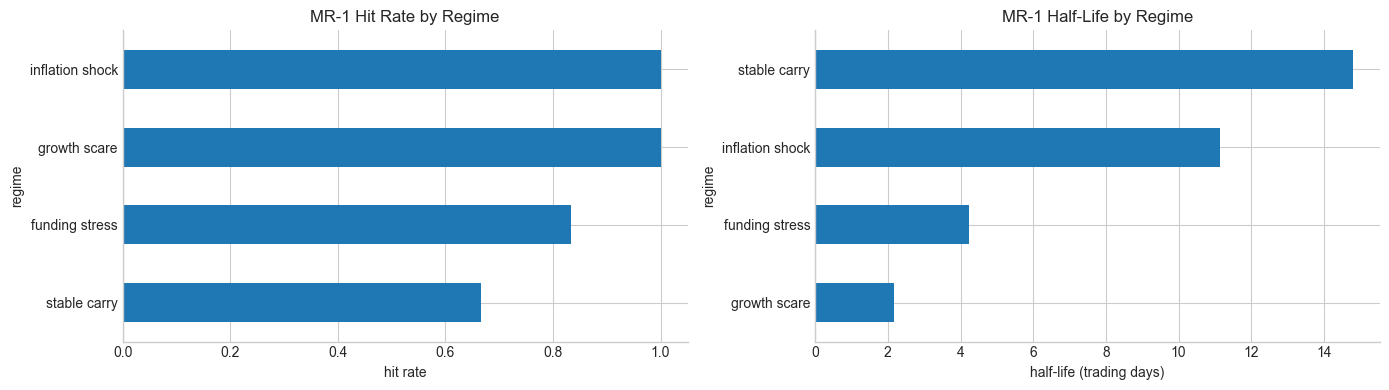

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mr_regime_summary["hit_rate"].sort_values().plot(kind='barh', ax=axes[0], title='MR-1 Hit Rate by Regime')
axes[0].set_xlabel('hit rate')

mr_regime_summary["half_life"].sort_values().plot(kind='barh', ax=axes[1], title='MR-1 Half-Life by Regime')
axes[1].set_xlabel('half-life (trading days)')
plt.tight_layout()
plt.show()
